In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed 
np.random.seed(42)

In [128]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("Spectral", n_colors=12)

sns.color_palette("Spectral", n_colors=12)


[(0.7803152633602461, 0.182160707420223, 0.2968089196462899),
 (0.8996539792387543, 0.340715109573241, 0.2848904267589389),
 (0.9679354094579008, 0.5074202229911572, 0.2996539792387543),
 (0.9923875432525952, 0.6938869665513263, 0.3900807381776239),
 (0.9954632833525567, 0.8476739715494039, 0.519261822376009),
 (0.9985390234525182, 0.9547097270280661, 0.6730488273740869),
 (0.9634755863129566, 0.9853902345251826, 0.6920415224913495),
 (0.8656670511341794, 0.9460207612456749, 0.6034602076124567),
 (0.6841983852364477, 0.8722029988465976, 0.6403690888119954),
 (0.48489042675893923, 0.7940023068050751, 0.6458285274894272),
 (0.30403690888119955, 0.6537485582468281, 0.6913494809688582),
 (0.24006151480199922, 0.47635524798154555, 0.7141868512110727)]

# 1. Handling the data

In [129]:
df = pd.read_csv('forPython_try2.csv', sep = ';', decimal = ',')
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
0,Before thawing,US,0.0000,0.0000,0.00000,0.0000,0.00000,0.0000,0.00000,0.9940,0.00,0.0000,0.000,0.00600
1,Before thawing - Pre-sort,cDC1 no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
2,Before thawing - Pre-sort,cDC1 change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
3,Before thawing - Pre-sort,cDC1 change 1 of 2,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
4,Before thawing - Pre-sort,HSC no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904


In [130]:
# Drop columns where sample is US 
df = df[df['Sample'] != 'US']
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Before thawing - Pre-sort,cDC1 no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
2,Before thawing - Pre-sort,cDC1 change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
3,Before thawing - Pre-sort,cDC1 change 1 of 2,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
4,Before thawing - Pre-sort,HSC no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
5,Before thawing - Pre-sort,HSC change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904


In [131]:
df[df["Time"] == "Day 1"]

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
21,Day 1,cDC1 no change,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
22,Day 1,cDC1 change everyday,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
23,Day 1,cDC1 change 1 of 2,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
24,Day 1,HSC no change,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
25,Day 1,HSC change everyday,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
26,Day 1,HSC change 1 of 2,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [132]:
df_day1 = df[df["Time"] == "Day 1"]
df_day1_cDC1_nochange = df_day1[df_day1["Sample"] == "cDC1 no change"]
df_day1_cDC1_change_everyday = df_day1[df_day1["Sample"] == "cDC1 change eveyday"]
df_day1_HSC_nochange = df_day1[df_day1["Sample"] == "HSC no change"]
df_day1_HSC_change1of2 = df_day1[df_day1["Sample"] == "HSC change 1 of 2"]


# 2. Preprocessing

In [133]:
def split_by_day (dataframe):
    sample_days = {}
    for day in dataframe["Time"].unique():
        sample_days[day] = dataframe[dataframe["Time"] == day]
    return sample_days

In [134]:
def split_by_sample(df):
    sample_dict = {}
    for sample_name in df["Sample"].unique():
        sample_dict[sample_name] = df[df["Sample"] == sample_name]

    return sample_dict


In [135]:
results_by_day = split_by_day(df)

## DCP proportions

In [136]:
# Keep only the DCP proportions
dcp_proportions = df.pivot(index='Time', columns='Sample', values='DCPs')
dcp_proportions

Sample,HSC change 1 of 2,HSC change everyday,HSC no change,cDC1 change 1 of 2,cDC1 change everyday,cDC1 no change
Time,,,,,,
Before thawing - Pre-sort,0.2100,0.2100,0.2100,0.2100,0.2100,0.2100
Before thawing - Sorted,0.3030,0.3030,0.3030,0.3030,0.3030,0.3030
Day 0,0.6150,0.6150,0.6150,0.6150,0.6150,0.6150
Day 1,0.0957,0.0711,0.0711,0.0709,0.0838,0.0709
Day 2,0.3270,0.2440,0.2710,0.2450,0.1860,0.2120
Day 3,0.3540,0.2810,0.3270,0.3540,0.4010,0.3200
Day 4,0.1680,0.1800,0.1450,0.1810,0.1810,0.1530
Day 5,0.0432,0.0431,0.0676,0.0392,0.0738,0.0482
Day 6,0.0145,0.0249,0.0179,0.0134,0.0247,0.0146


In [137]:
df_before_thawing = df[df["Time"] == "Before thawing"].copy()
df_day0 = df[df["Time"] == "Day 0"]

# Add df_day 0 after df_before thawing
df_1st_days = pd.concat([df_before_thawing, df_day0], ignore_index=True)

df_1st_days = df_1st_days.set_index("Sample")
df_1st_days

,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
Sample,,,,,,,,,,,,,
cDC1 no change,Day 0,0.002,0.034,0.0164,0.0008,0.0028,0.0692,0.0,0.0512,0.615,0.0012,0.01,0.1974
cDC1 change everyday,Day 0,0.002,0.034,0.0164,0.0008,0.0028,0.0692,0.0,0.0512,0.615,0.0012,0.01,0.1974
cDC1 change 1 of 2,Day 0,0.002,0.034,0.0164,0.0008,0.0028,0.0692,0.0,0.0512,0.615,0.0012,0.01,0.1974
HSC no change,Day 0,0.002,0.034,0.0164,0.0008,0.0028,0.0692,0.0,0.0512,0.615,0.0012,0.01,0.1974
HSC change everyday,Day 0,0.002,0.034,0.0164,0.0008,0.0028,0.0692,0.0,0.0512,0.615,0.0012,0.01,0.1974
HSC change 1 of 2,Day 0,0.002,0.034,0.0164,0.0008,0.0028,0.0692,0.0,0.0512,0.615,0.0012,0.01,0.1974


# 3. Figures

## Proportion of cell types

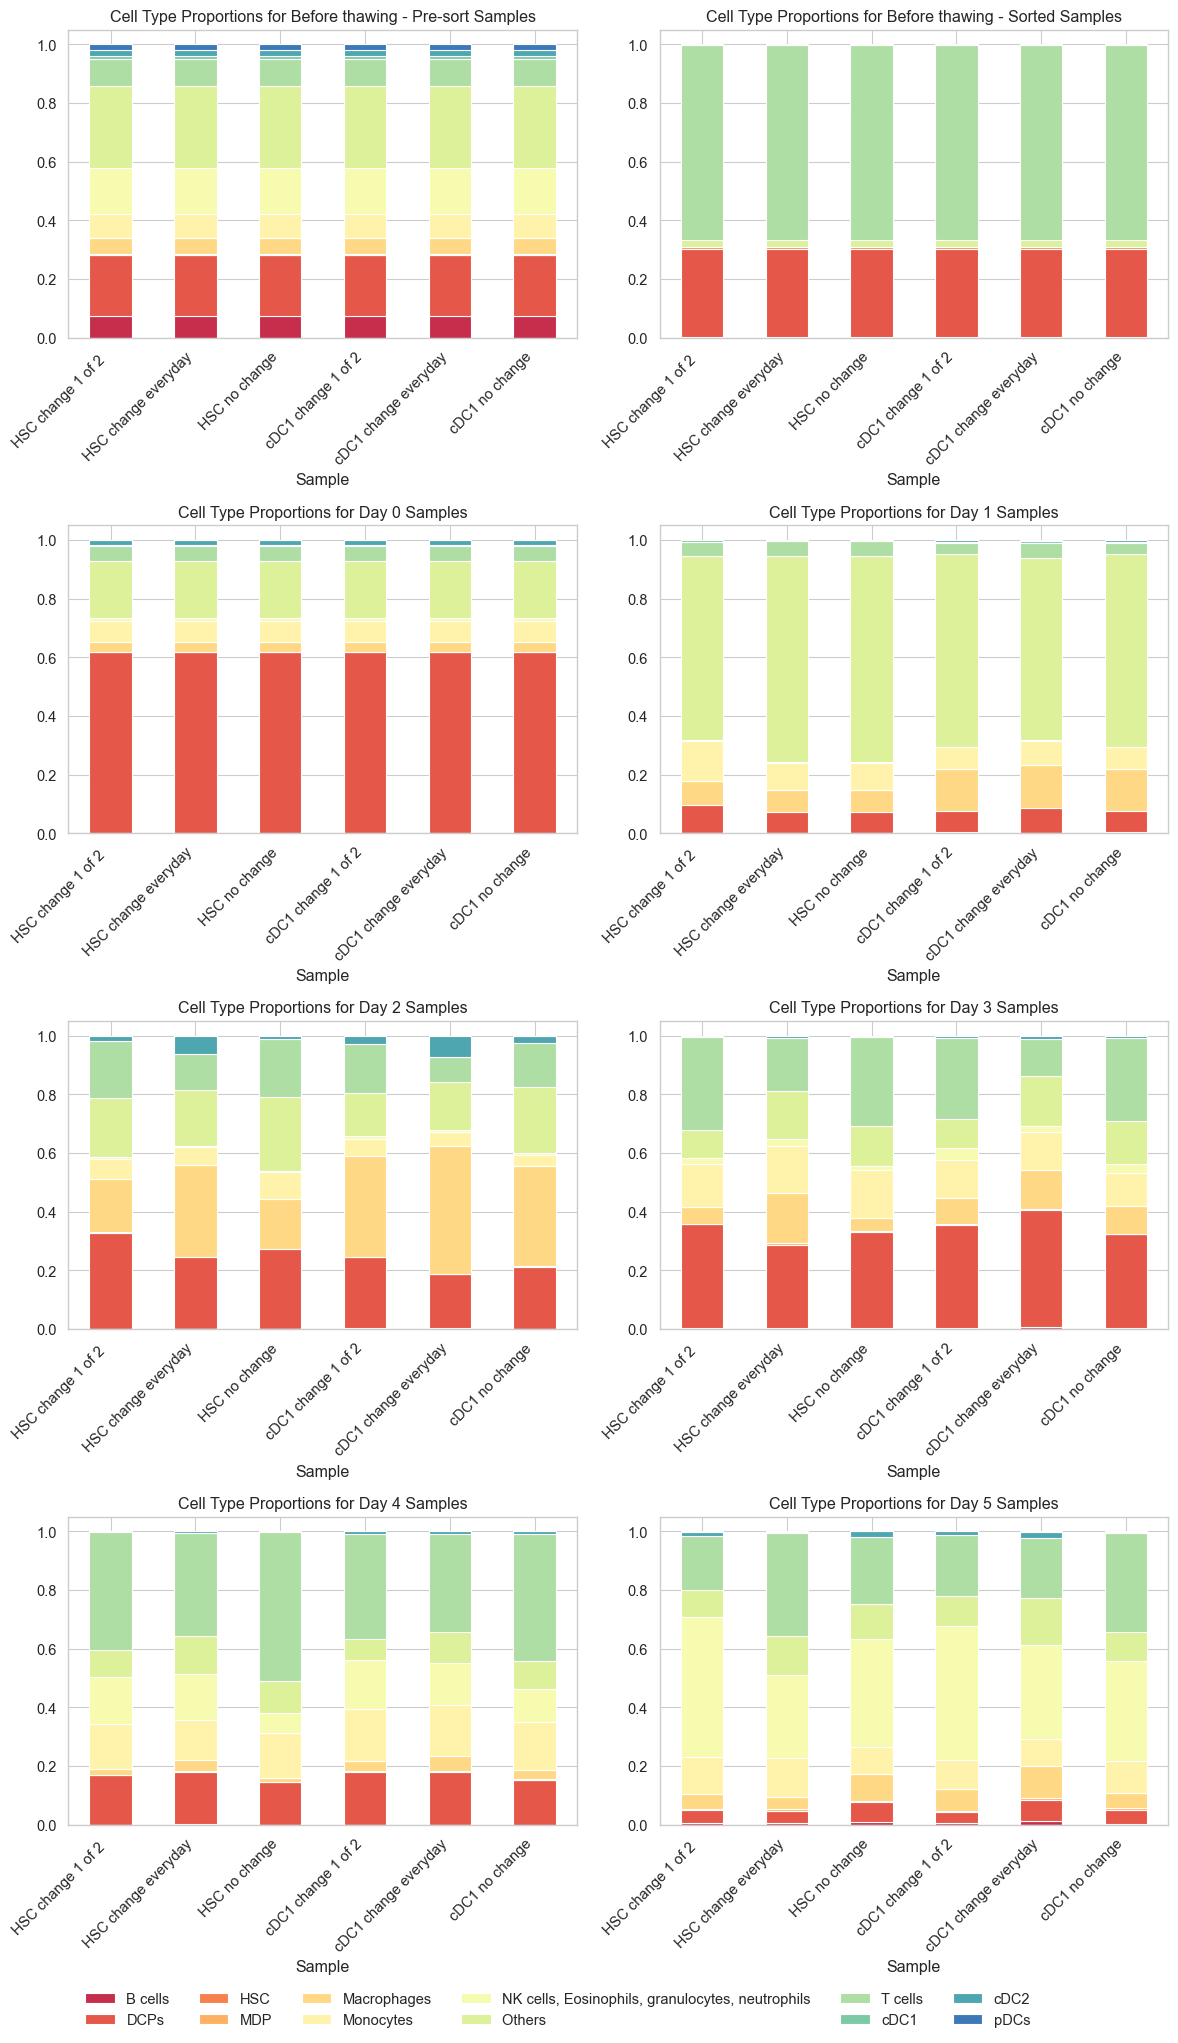

In [138]:
# Plot a figure with the 6 days with 3 lines and 2 columns
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))
days = list(results_by_day.keys())
for i, ax in enumerate(axes.flatten()):
    if i < len(days):
        day = days[i]
        day_data = results_by_day[day]
        day_proportions = pd.DataFrame()
        
        for sample_name, sample_data in split_by_sample(day_data).items():
            sample_proportions = sample_data.iloc[:, 2:].copy()
            sample_proportions.insert(0, "Sample", sample_name)
            day_proportions = pd.concat([day_proportions, sample_proportions], ignore_index=True)
        
        day_proportions_plot = day_proportions.melt(id_vars='Sample', var_name='Cell Type', value_name='Proportion')
        day_proportions_plot_pivot = day_proportions_plot.pivot(index='Sample', columns='Cell Type', values='Proportion')
        day_proportions_plot_pivot.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'Cell Type Proportions for {day} Samples')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.legend_.remove()

plt.tight_layout()

plt.legend(
    loc='upper center',
    bbox_to_anchor=(-0.2, -0.5),
    ncol =6,
    frameon=False
)
plt.savefig('Figures/DCP_proportions_across_days.png', dpi=300, bbox_inches='tight')
plt.show()

## DCP proportions

<Figure size 1000x600 with 0 Axes>

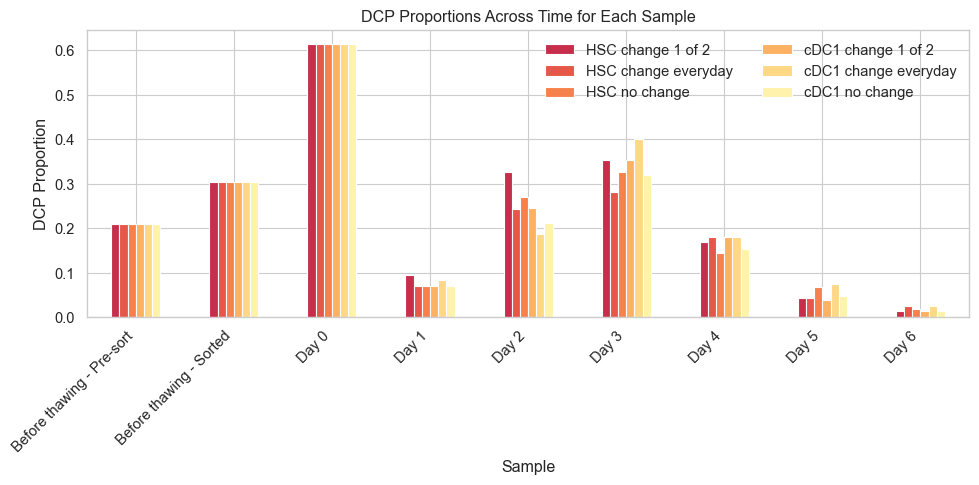

In [140]:
# Plot bar chart of DCP proportions across time for each sample
plt.figure(figsize=(10, 6))
dcp_proportions.plot(kind='bar', figsize=(10,5))
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title="", frameon=False, ncol=2)
plt.tight_layout()
plt.show()  